In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import sys
import os
import seaborn as sns
from scipy import stats as scipystats


from scipy.stats import mannwhitneyu, normaltest
import math
from statsmodels.stats.anova import AnovaRM
# import pingouin as pg
import seaborn.objects as so
#from joypy import joyplot


pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 150)
pd.set_option('display.precision', 3)
pd.set_option('display.expand_frame_repr', False)




In [2]:
df = pd.read_csv(r'C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\final_10_reps_combined.csv')

newdata_df = df[
                (df['rep'] == 5)|(df['rep'] == 6)
                |
                (df['rep'] == 7)|(df['rep'] == 8)
                |
                (df['rep'] == 9)|(df['rep'] == 10)
                ]


In [3]:
anova_df = newdata_df[['strain', 'rep','time_since_switch_hrs', 'CV', 'OD600', 'true_mean_cell_vol_fl']]
anova_df['subject'] = "tba"
anova_df = anova_df.drop_duplicates(keep= 'first').reset_index(drop = True)
import warnings 
with warnings.catch_warnings(record=True):
    for row in anova_df.index:
        if ((anova_df['strain'].loc[row]) == "whi5_bck2_dd") & ((anova_df['rep'].loc[row]) == 5):
            anova_df['subject'].loc[row] = "dd_rep5"
        elif ((anova_df['strain'].loc[row]) == "whi5_bck2_dd") & ((anova_df['rep'].loc[row]) == 6):
            anova_df['subject'].loc[row] = "dd_rep6"
        elif ((anova_df['strain'].loc[row]) == "whi5_bck2_dd") & ((anova_df['rep'].loc[row]) == 7):
            anova_df['subject'].loc[row] = "dd_rep7"
        elif ((anova_df['strain'].loc[row]) == "whi5_bck2_dd") & ((anova_df['rep'].loc[row]) == 8):
            anova_df['subject'].loc[row] = "dd_rep8"
        elif ((anova_df['strain'].loc[row]) == "whi5_bck2_dd") & ((anova_df['rep'].loc[row]) == 9):
            anova_df['subject'].loc[row] = "dd_rep9"
        elif ((anova_df['strain'].loc[row]) == "whi5_bck2_dd") & ((anova_df['rep'].loc[row]) == 10):
            anova_df['subject'].loc[row] = "dd_rep10"
        elif ((anova_df['strain'].loc[row]) == "MMY") & ((anova_df['rep'].loc[row]) == 5):
            anova_df['subject'].loc[row] = "MMY_rep5"
        elif ((anova_df['strain'].loc[row]) == "MMY") & ((anova_df['rep'].loc[row]) == 6):
            anova_df['subject'].loc[row] = "MMY_rep6"
        elif ((anova_df['strain'].loc[row]) == "MMY") & ((anova_df['rep'].loc[row]) == 7):
            anova_df['subject'].loc[row] = "MMY_rep7"
        elif ((anova_df['strain'].loc[row]) == "MMY") & ((anova_df['rep'].loc[row]) == 8):
            anova_df['subject'].loc[row] = "MMY_rep8"
        elif ((anova_df['strain'].loc[row]) == "MMY") & ((anova_df['rep'].loc[row]) == 9):
            anova_df['subject'].loc[row] = "MMY_rep9"
        elif ((anova_df['strain'].loc[row]) == "MMY") & ((anova_df['rep'].loc[row]) == 10):
            anova_df['subject'].loc[row] = "MMY_rep10"

#display(anova_df)



C:\Users\timon\AppData\Local\Temp\ipykernel_19884\2629467976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anova_df['subject'] = "tba"


# ***Fig 2B: plotting cell vol vs time since switch*** 

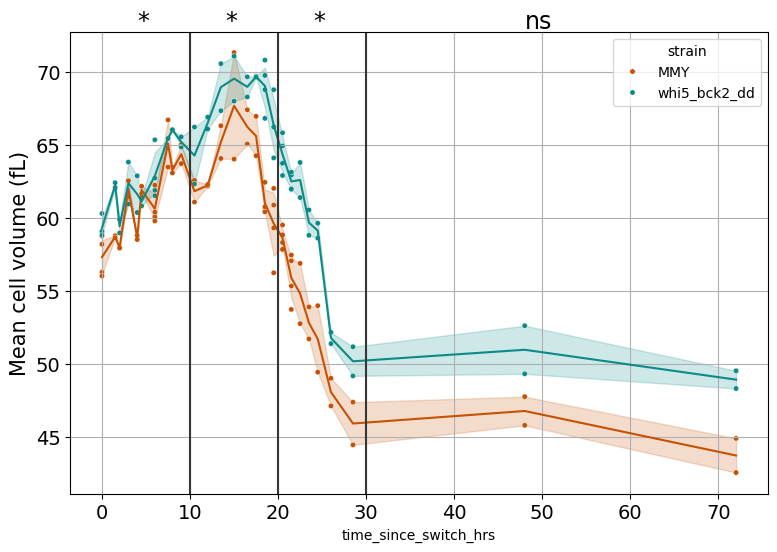

In [7]:
plt.figure(figsize=(9, 6))
palette2 ={"MMY": "#c65102", "whi5_bck2_dd": "#0b8b87"}

l = sns.lineplot(data=anova_df, y = 'true_mean_cell_vol_fl', x = 'time_since_switch_hrs', color="b", palette = palette2,hue = 'strain',  legend  =False)
sns.scatterplot(data=anova_df, y = 'true_mean_cell_vol_fl', x = 'time_since_switch_hrs', color="b", hue = 'strain',s =15, palette = palette2)


l.set_ylabel("Mean cell volume (fL)", fontsize=15)

l.tick_params(axis='both', which='major', labelsize=14)

plt.axvline(10, 0,1, color='#363737')
plt.axvline(20, 0,1, color='#363737')
plt.axvline(30, 0,1, color='#363737')
plt.text(4, 73, "*", fontsize=17)
plt.text(14, 73, "*", fontsize=17)
plt.text(24, 73, "*", fontsize=17)
plt.text(48, 73, "ns", fontsize=17)

plt.grid()

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig2\panel2_withedits_100924.svg")

In [14]:
# Check for normality

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
import importlib
import core
importlib.reload(core)

print(anova_df['time_since_switch_hrs'].value_counts())

# bin data into time intervals, 0-10, 10-20, 20-30, 30 open end
bins = [0, 10, 20, 30, float('inf')]
anova_df['time_bin'] = pd.cut(anova_df['time_since_switch_hrs'], bins=bins)
print(anova_df['time_bin'].value_counts())

core.run_stats(
    anova_df[anova_df['time_since_switch_hrs'] < 30],
    value_cols=['true_mean_cell_vol_fl', 'CV'],
    group_col=['strain', 'time_bin'],
)

time_since_switch_hrs
0.0     8
18.5    8
6.0     8
21.5    8
20.5    8
19.5    8
2.0     4
4.0     4
8.0     4
22.5    4
23.5    4
24.5    4
26.0    4
28.5    4
1.5     4
3.0     4
4.5     4
7.5     4
9.0     4
10.5    4
12.0    4
13.5    4
15.0    4
16.5    4
17.5    4
48.0    4
72.0    4
Name: count, dtype: int64
time_bin
(0.0, 10.0]     40
(10.0, 20.0]    40
(20.0, 30.0]    36
(30.0, inf]      8
Name: count, dtype: int64

Group: '['strain', 'time_bin']'  |  Value: 'true_mean_cell_vol_fl'


,time_bin,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(MMY, (10.0, 20.0])",20,63.0,62.4,0.51,1,Shapiro-Wilk,0.612,True
1,"(whi5_bck2_dd, (20.0, 30.0])",18,59.7,61.7,-0.92,3,Shapiro-Wilk,0.009,False
2,"(MMY, (0.0, 10.0])",20,61.3,61.6,0.32,0,Shapiro-Wilk,0.330,True
3,"(whi5_bck2_dd, (10.0, 20.0])",20,67.9,68.2,-0.63,0,Shapiro-Wilk,0.295,True
4,"(MMY, (20.0, 30.0])",18,53.6,54.0,-0.50,0,Shapiro-Wilk,0.223,True
5,"(whi5_bck2_dd, (0.0, 10.0])",20,62.9,62.6,0.01,0,Shapiro-Wilk,0.139,True


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,20,8.040e-02,7.980e-02,7.640e-02,False,False,False,False
1,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,18,0.000e+00,0.000e+00,0.000e+00,True,True,True,False
2,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,20,3.970e-02,3.970e-02,5.650e-02,True,True,False,True
3,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,20,0.000e+00,0.000e+00,0.000e+00,True,True,True,False
4,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,18,2.310e-01,2.119e-01,8.037e-01,False,False,False,False
5,"('MMY', Interval(10.0, 20.0, closed='right')) ...",20,18,0.000e+00,0.000e+00,0.000e+00,True,True,True,False
6,"('MMY', Interval(10.0, 20.0, closed='right')) ...",20,20,9.304e-01,9.303e-01,9.676e-01,False,False,False,False
7,"('MMY', Interval(10.0, 20.0, closed='right')) ...",20,20,0.000e+00,0.000e+00,1.000e-04,True,True,True,False
8,"('MMY', Interval(10.0, 20.0, closed='right')) ...",20,18,2.720e-02,2.270e-02,8.190e-02,True,True,False,True
9,"('MMY', Interval(20.0, 30.0, closed='right')) ...",18,20,0.000e+00,0.000e+00,0.000e+00,True,True,True,False



Group: '['strain', 'time_bin']'  |  Value: 'CV'


,time_bin,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(MMY, (10.0, 20.0])",20,0.7,0.7,-0.24,0,Shapiro-Wilk,0.580,True
1,"(whi5_bck2_dd, (20.0, 30.0])",18,0.6,0.7,-1.22,4,Shapiro-Wilk,0.001,False
2,"(MMY, (0.0, 10.0])",20,0.5,0.5,0.82,0,Shapiro-Wilk,0.123,True
3,"(whi5_bck2_dd, (10.0, 20.0])",20,0.7,0.7,-0.67,0,Shapiro-Wilk,0.041,False
4,"(MMY, (20.0, 30.0])",18,0.6,0.6,-0.75,0,Shapiro-Wilk,0.076,True
5,"(whi5_bck2_dd, (0.0, 10.0])",20,0.5,0.5,0.16,0,Shapiro-Wilk,0.628,True


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,20,0.000e+00,0.000e+00,0.000e+00,True,True,True,False
1,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,18,0.000e+00,0.000e+00,0.000e+00,True,True,True,False
2,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,20,2.374e-01,2.374e-01,2.287e-01,False,False,False,False
3,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,20,0.000e+00,0.000e+00,0.000e+00,True,True,True,False
4,"('MMY', Interval(0.0, 10.0, closed='right')) v...",20,18,0.000e+00,0.000e+00,0.000e+00,True,True,True,False
5,"('MMY', Interval(10.0, 20.0, closed='right')) ...",20,18,0.000e+00,0.000e+00,0.000e+00,True,True,True,False
6,"('MMY', Interval(10.0, 20.0, closed='right')) ...",20,20,0.000e+00,0.000e+00,0.000e+00,True,True,True,False
7,"('MMY', Interval(10.0, 20.0, closed='right')) ...",20,20,1.000e-04,1.000e-04,5.000e-04,True,True,True,False
8,"('MMY', Interval(10.0, 20.0, closed='right')) ...",20,18,1.100e-03,6.000e-04,6.000e-04,True,True,True,False
9,"('MMY', Interval(20.0, 30.0, closed='right')) ...",18,20,0.000e+00,0.000e+00,0.000e+00,True,True,True,False


# ***Fig 2C:plotting OD vs time since switch*** 

C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

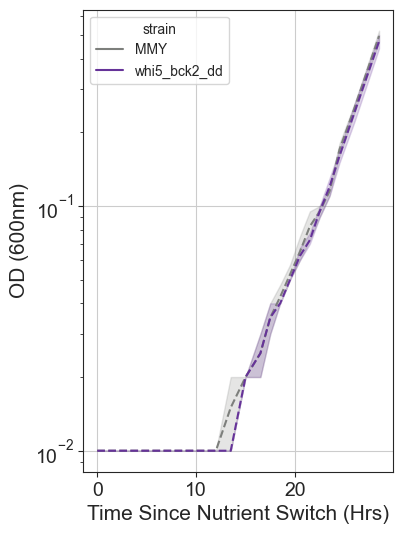

In [ ]:
plt.figure(figsize=(4, 6))
l = sns.lineplot(data=anova_df[anova_df['time_since_switch_hrs'] < 30], y = 'OD600', x = 'time_since_switch_hrs',  hue = 'strain', palette = palette, linestyle='--')
#l.legend(loc='lower left')
l.set_xlabel("Time Since Nutrient Switch (Hrs)", fontsize=15)
l.set_ylabel("OD (600nm)", fontsize=15)
l.set_yscale('log')
l.tick_params(axis='both', which='major', labelsize=14)
plt.grid()
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig2\panel2_inset_100924.svg")

# ***Fig 2D: plotting CV vs time since switch*** 

C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

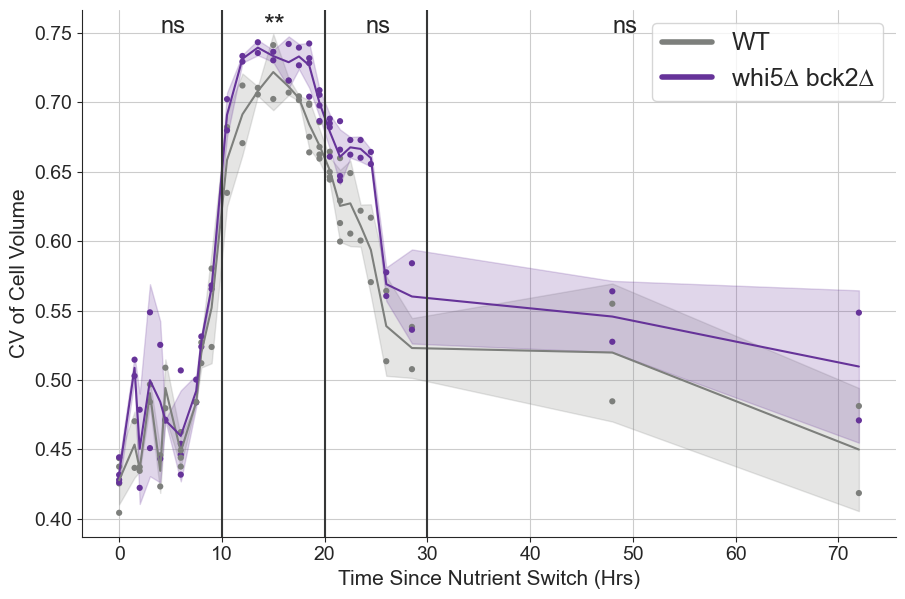

In [ ]:
sns.set_style("ticks")
palette ={"MMY": "#7d7f7c", "whi5_bck2_dd": "rebeccapurple"}
f1 = sns.relplot(data=anova_df, x = "time_since_switch_hrs", y = "CV", kind = "line", errorbar = "sd", hue="strain", height = 6, aspect =1.5, palette = palette, legend = False)
ax1 = sns.scatterplot(data=anova_df, x = "time_since_switch_hrs", y = "CV", hue="strain", linewidth = 0, s = 20, legend = False, palette = palette)
ax1.axvline(10, 0,1, color='#363737')
ax1.axvline(20, 0,1, color='#363737')
ax1.axvline(30, 0,1, color='#363737')
ax1.text(4, 0.75, "ns", fontsize=17)
ax1.text(14, 0.75, "**", fontsize=20)
ax1.text(24, 0.75, "ns", fontsize=17)
ax1.text(48, 0.75, "ns", fontsize=17)
ax1.set_xlabel("Time Since Nutrient Switch (Hrs)", fontsize=15)
ax1.set_ylabel("CV of Cell Volume", fontsize=15)


mylabels = ["WT", "whi5∆ bck2∆"]
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color="#7d7f7c", lw=4),
                Line2D([0], [0], color="rebeccapurple", lw=4)]
ax1.legend(custom_lines, ['WT', 'whi5∆ bck2∆'], facecolor = "white", fontsize=18)



plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid()
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig2\panel1.svg")

plt.show()


# ***pg.mixed_anova does not work with timepoints differing between reps because it does not tolerate Nans*** 

# ***creating anova df with equal timepoints between reps (taking means) to perform pg.mixed_Anova*** 

In [ ]:
#### taking means of only timepoints with four reps to get two reps per timept because pg.mixed_anova des not accept nans

anova_df = anova_df.sort_values(by = ['strain','time_since_switch_hrs'])
anova_df.loc[(anova_df['rep'] == 5) | (anova_df['rep'] == 6), 'rep_pair'] = '5/6'
anova_df.loc[(anova_df['rep'] == 7) | (anova_df['rep'] == 8), 'rep_pair'] = '7/8'
anova_df.loc[(anova_df['rep'] == 9) | (anova_df['rep'] == 10), 'rep_pair'] = '9/10'
#display(anova_df)
new=[]

with warnings.catch_warnings(record=True):
    for strain in anova_df['strain'].unique():
        strain_df = anova_df[anova_df['strain'] == strain]
        for timept in strain_df['time_since_switch_hrs'].unique():
            timept_df = strain_df[strain_df['time_since_switch_hrs'] == timept]
            if len(timept_df) > 2:
                n = 0
                for reppair in timept_df['rep_pair'].unique():
                    n = n+1
                    reppair_df = timept_df[timept_df['rep_pair'] == reppair]
                    mean_cv = reppair_df['CV'].mean()
                    mean_OD = reppair_df['OD600'].mean()
                    mean_rep = reppair_df['rep'].mean()
                    mean_cellvol = reppair_df['true_mean_cell_vol_fl'].mean() 
                    app_data = {'index': [1], 'strain': strain, 'time_since_switch_hrs': timept, 'rep_pair': reppair, 'rep': mean_rep,
                               'true_mean_cell_vol_fl' : mean_cellvol, 'CV': mean_cv, 'OD600': mean_OD, 'theoretical_rep': n}
                    toapp = pd.DataFrame.from_dict(app_data)
                    new.append(toapp)
            else:
                timept_df['theoretical_rep'] = 0
                timept_df['theoretical_rep'].iloc[0] = 1
                timept_df['theoretical_rep'].iloc[1] = 2
                new.append (timept_df)

equaltimepts_anova_df = pd.concat(new).reset_index(drop = True)
equaltimepts_anova_df['subject'] = equaltimepts_anova_df["strain"] + equaltimepts_anova_df["theoretical_rep"].astype(str) 
display(equaltimepts_anova_df)



,index,strain,time_since_switch_hrs,rep_pair,rep,true_mean_cell_vol_fl,CV,OD600,theoretical_rep,subject
0,1.0,MMY,0.0,5/6,5.5,58.494,0.415,0.010,1,MMY1
1,1.0,MMY,0.0,7/8,7.5,56.171,0.441,0.010,2,MMY2
2,NaN,MMY,1.5,7/8,7.0,58.801,0.470,0.010,1,MMY1
3,NaN,MMY,1.5,7/8,8.0,58.660,0.437,0.010,2,MMY2
4,NaN,MMY,2.0,5/6,5.0,58.015,0.435,0.010,1,MMY1
5,NaN,MMY,2.0,5/6,6.0,57.953,0.437,0.010,2,MMY2
6,NaN,MMY,3.0,7/8,7.0,61.455,0.484,0.010,1,MMY1
7,NaN,MMY,3.0,7/8,8.0,62.566,0.497,0.010,2,MMY2
8,NaN,MMY,4.0,5/6,5.0,58.802,0.423,NaN,1,MMY1
9,NaN,MMY,4.0,5/6,6.0,58.539,0.446,NaN,2,MMY2


# ***pg.mixed_Anova for CV and cell vol in equaltimepts_anova_df*** 

In [ ]:

early_df = equaltimepts_anova_df[equaltimepts_anova_df['time_since_switch_hrs']<10]
early_df_aov = pg.mixed_anova(dv='CV', between='strain', within='time_since_switch_hrs', subject='subject', data=early_df)
early_df_aov['timeframe'] = "0to10_hrs_after_switch"
mid_df = equaltimepts_anova_df[(equaltimepts_anova_df['time_since_switch_hrs']>=10) & (equaltimepts_anova_df['time_since_switch_hrs']<20)]
mid_df_aov = pg.mixed_anova(dv='CV', between='strain', within='time_since_switch_hrs', subject='subject', data=mid_df)
mid_df_aov['timeframe'] = "10to20_hrs_after_switch"
late_df = equaltimepts_anova_df[(equaltimepts_anova_df['time_since_switch_hrs']>=20)& (equaltimepts_anova_df['time_since_switch_hrs']<30)]
late_df_aov = pg.mixed_anova(dv='CV', between='strain', within='time_since_switch_hrs', subject='subject', data=late_df)
late_df_aov['timeframe'] = "20to30_hrs_after_switch"
vlate_df = equaltimepts_anova_df[(equaltimepts_anova_df['time_since_switch_hrs']>=30)]
vlate_df_aov = pg.mixed_anova(dv='CV', between='strain', within='time_since_switch_hrs', subject='subject', data=vlate_df)
vlate_df_aov['timeframe'] = ">=30_hrs_after_switch"
equaltimepts_CV_mixedanova_summary = pd.concat([early_df_aov,mid_df_aov, late_df_aov, vlate_df_aov])
#equaltimepts_CV_mixedanova_summary.to_csv('C:/Users/yagya.chadha/Desktop/Yagya/Coulter Counter/medium switch/equaltimepts_CV_mixedanova_summary.csv')
display(equaltimepts_CV_mixedanova_summary)

early_df = equaltimepts_anova_df[equaltimepts_anova_df['time_since_switch_hrs']<10]
early_df_aov = pg.mixed_anova(dv='true_mean_cell_vol_fl', between='strain', within='time_since_switch_hrs', subject='subject', data=early_df)
early_df_aov['timeframe'] = "0to10_hrs_after_switch"
mid_df = equaltimepts_anova_df[(equaltimepts_anova_df['time_since_switch_hrs']>=10) & (equaltimepts_anova_df['time_since_switch_hrs']<20)]
mid_df_aov = pg.mixed_anova(dv='true_mean_cell_vol_fl', between='strain', within='time_since_switch_hrs', subject='subject', data=mid_df)
mid_df_aov['timeframe'] = "10to20_hrs_after_switch"
late_df = equaltimepts_anova_df[(equaltimepts_anova_df['time_since_switch_hrs']>=20)& (equaltimepts_anova_df['time_since_switch_hrs']<30)]
late_df_aov = pg.mixed_anova(dv='true_mean_cell_vol_fl', between='strain', within='time_since_switch_hrs', subject='subject', data=late_df)
late_df_aov['timeframe'] = "20to30_hrs_after_switch"
vlate_df = equaltimepts_anova_df[(equaltimepts_anova_df['time_since_switch_hrs']>=30)]
vlate_df_aov = pg.mixed_anova(dv='true_mean_cell_vol_fl', between='strain', within='time_since_switch_hrs', subject='subject', data=vlate_df)
vlate_df_aov['timeframe'] = ">=30_hrs_after_switch"
equaltimepts_cellvol_mixedanova_summary = pd.concat([early_df_aov,mid_df_aov, late_df_aov, vlate_df_aov])
#equaltimepts_cellvol_mixedanova_summary.to_csv('C:/Users/yagya.chadha/Desktop/Yagya/Coulter Counter/medium switch/equaltimepts_cellvol_mixedanova_summary.csv')
display(equaltimepts_cellvol_mixedanova_summary)





C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\pingouin\distribution.py:1004: RuntimeWarning: divide by zero encountered in double_scalars
  W = np.prod(eig) / (eig.sum() / d) ** d


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps,timeframe
0,strain,2.333e-03,1,2,2.333e-03,5.336,1.471e-01,0.727,NaN,0to10_hrs_after_switch
1,time_since_switch_hrs,5.374e-02,9,18,5.972e-03,8.023,1.019e-04,0.800,0.222,0to10_hrs_after_switch
2,Interaction,4.537e-03,9,18,5.041e-04,0.677,7.195e-01,0.253,NaN,0to10_hrs_after_switch
0,strain,6.991e-03,1,2,6.991e-03,511.954,1.948e-03,0.996,NaN,10to20_hrs_after_switch
1,time_since_switch_hrs,1.027e-02,7,14,1.467e-03,4.859,5.828e-03,0.708,0.247,10to20_hrs_after_switch
2,Interaction,7.602e-04,7,14,1.086e-04,0.360,9.109e-01,0.152,NaN,10to20_hrs_after_switch
0,strain,1.221e-02,1,2,1.221e-02,7.743,1.085e-01,0.795,NaN,20to30_hrs_after_switch
1,time_since_switch_hrs,5.667e-02,6,12,9.445e-03,39.140,3.395e-07,0.951,0.363,20to30_hrs_after_switch
2,Interaction,1.175e-03,6,12,1.958e-04,0.811,5.809e-01,0.289,NaN,20to30_hrs_after_switch
0,strain,3.677e-03,1,2,3.677e-03,2.253,2.721e-01,0.530,NaN,>=30_hrs_after_switch


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps,timeframe
0,strain,24.864,1,2,24.864,43.599,2.218e-02,0.956,NaN,0to10_hrs_after_switch
1,time_since_switch_hrs,222.606,9,18,24.734,23.941,3.033e-08,0.923,0.276,0to10_hrs_after_switch
2,Interaction,16.831,9,18,1.870,1.810,1.357e-01,0.475,NaN,0to10_hrs_after_switch
0,strain,143.794,1,2,143.794,35.075,2.735e-02,0.946,NaN,10to20_hrs_after_switch
1,time_since_switch_hrs,137.402,7,14,19.629,4.545,7.765e-03,0.694,0.264,10to20_hrs_after_switch
2,Interaction,31.961,7,14,4.566,1.057,4.377e-01,0.346,NaN,10to20_hrs_after_switch
0,strain,256.535,1,2,256.535,30.253,3.150e-02,0.938,NaN,20to30_hrs_after_switch
1,time_since_switch_hrs,588.673,6,12,98.112,65.973,1.726e-08,0.971,0.409,20to30_hrs_after_switch
2,Interaction,14.623,6,12,2.437,1.639,2.195e-01,0.450,NaN,20to30_hrs_after_switch
0,strain,44.123,1,2,44.123,17.223,5.345e-02,0.896,NaN,>=30_hrs_after_switch
